## 将06文档中的核心部分摘出来，得到最终模型

In [54]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [55]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv') 

In [56]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [57]:
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ','_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [58]:
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [59]:
df_full_train,df_test = train_test_split(df, test_size=0.2, random_state=1)

In [60]:
len(df_full_train),len(df_test)

(5634, 1409)

In [61]:
df_train,df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [62]:
len(df_full_train),len(df_test),len(df_train),len(df_val)

(5634, 1409, 4225, 1409)

In [63]:
y_train = df_train.churn.values 
y_val = df_val.churn.values 
y_test = df_test.churn.values 

In [29]:
#del df_train['churn']
#del df_val['churn']
#del df_test['churn']

In [70]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents','phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling','paymentmethod']

In [71]:
numerical = ['tenure','monthlycharges','totalcharges']

In [72]:
def train(df_train, y_train,C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(C=C,solver='liblinear',max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [73]:
def predict(df_train, dv, model):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]
    return y_pred 

In [84]:
n_splits = 5
C = 1.0 
scores = []
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

In [85]:
for train_idx,val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val =  df_full_train.iloc[val_idx]
        y_train = df_train.churn.values
        y_val = df_val.churn.values
        
        dv,model = train(df_train, y_train ,C=C) 
        y_pred = predict(df_val,dv,model)
        auc =  roc_auc_score(y_val,y_pred)
        scores.append(auc)
print('%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

1.0 0.841 +- 0.007


In [88]:
scores

[0.8423240260300963,
 0.8453247086478611,
 0.8335059201284366,
 0.8323627454115241,
 0.8521736060995889]

In [89]:
dv,model = train(df_full_train, df_full_train.churn.values ,C=1) 
y_pred = predict(df_test,dv,model)
auc =  roc_auc_score(y_test,y_pred)
auc

0.8579400803839363

## 5.1 Intro / Session overview
What we will cover this week

### voerview --  **MLOps 模型部署与监控的全景图**
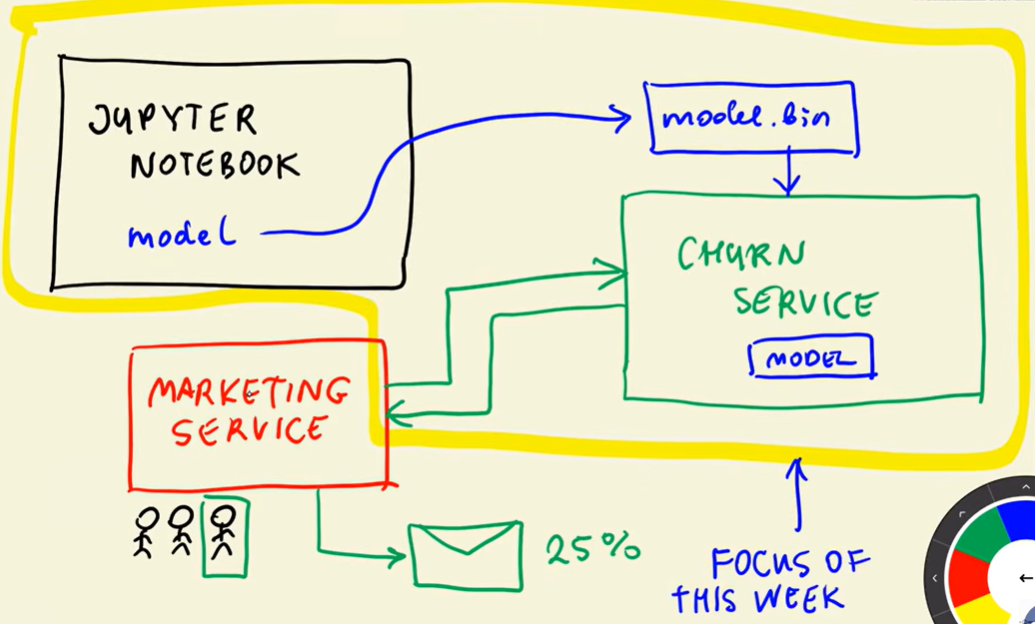


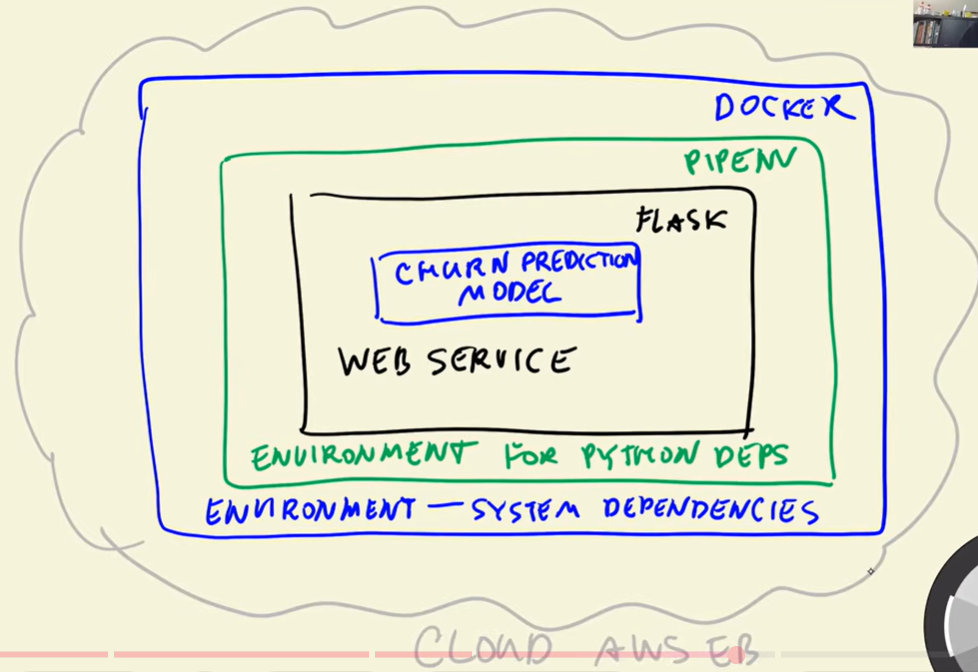


## 5.2 Saving and loading the model
- Saving the model to pickle
- Loading the model from pickle
- Turning our notebook into a Python script

### - Saving the model to pickle

In [90]:
import pickle  #  pickle  Python的“打包/拆包”工具，能将 Python 里的任何对象转换成“字节流”，并保存到文件中。

In [91]:
output_file = f'model_C={C}.bin'  #定义一个字符串变量 output_file，用来存放文件名。
output_file

'model_C=1.0.bin'

In [92]:
f_out = open(output_file,'wb')  #用 Python 内置的 open 函数打开一个文件,wb'：代表 Write Binary（以二进制模式写入）
pickle.dump((dv,model),f_out)  #模型数据就已经被写入到 f_out 指向的文件中了 
f_out.close()            # 关闭刚才打开的文件

In [93]:
# 上面的打开，写入数据，关闭文件，可以使用with语句实现
with open(output_file, 'wb') as f_out:
    pickle.dump((dv, model), f_out)

### - load the model to pickle

In [ ]:
import pickle 

In [99]:
model_file = 'model_C=1.0.bin'

In [100]:
# 读取文件内容
with open(model_file, 'rb') as f_in:
   dv, model =  pickle.load(f_in)

In [101]:
dv,model

(DictVectorizer(sparse=False),
 LogisticRegression(C=1, max_iter=1000, solver='liblinear'))

In [103]:
# 假设这个客户是新的用户信息
customer = {
'gender': 'female',
'seniorcitizen': 0,
'partner': 'yes',
'dependents': 'no',
'phoneservice': 'no',
'multiplelines': 'no_phone_service',
'internetservice': 'dsl',
'onlinesecurity':'no',
'onlinebackup': 'yes',
'deviceprotection':'no',
'techsupport':'no',
'streamingtv':'no',
'streamingmovies':'no',
'contract':'month-to-month',
'paperlessbilling': 'yes',
'paymentmethod':'electronic_check',
'tenure': 1,
'monthlycharges': 29.85,
'totalcharges': 29.85
}

In [106]:
# 先把这个用户数据做向量化
X = dv.transform([customer])

In [109]:
model.predict_proba(X)[:,1]

array([0.64330135])

In [112]:
# 将ipynb文件，转换为py后缀的脚本文件,会生成同名的py为后缀的文件，在同个目录中
!jupyter nbconvert --to script  07_deploying_machine_learning_models.ipynb

24544.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


[NbConvertApp] Converting notebook 07_deploying_machine_learning_models.ipynb to script
[NbConvertApp] Writing 6075 bytes to 07_deploying_machine_learning_models.py


## 5.3 Web services: introduction to Flask
- Writing a simple ping/pong app
- Querying it with 'curl' and browser

## 5.4 Serving the churn model with Flask
- Wrapping the predict script into a Flask app
- Querying it with 'requests'
- Preparing for production: gunicorn
- Running it on Windows with waitress

## 5.5 Dependency and environment management: Pipenv
- Why we need virtual environment
- Installing Pipenv
- Installing libraries with Pipenv
- Running things with Pipenv

## 5.6 Environment management: Docker
- Why we need Docker
- Running a Python image with docker
- Dockerfile
- Building a docker image
- Running a docker image

## 5.7 Deployment to the cloud: AWS Elastic Beanstalk (optional)
- Installing the eb cli
- Running eb locally
- Deploying the model

## 5.8 Explore more
- Flask is not the only framework for creating web services. Try others,e.g. FastAPI
- Experiment with other ways of managing environment, e.g. virtual env,conda, poetry.
- Explore other ways of deploying web services, e.g. GCP, Azure, Heroku,Python Anywhere, etc